In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

import mlflow
import mlflow.sklearn
from pathlib import Path

df = pd.read_csv("../data/processed/heart_clean.csv")

df.head()

print(df.shape)

df.info()

TRACKING_DIR = Path("../mlruns")
TRACKING_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(TRACKING_DIR.resolve().as_uri())
mlflow.set_experiment("Heart Disease Prediction")



(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


<Experiment: artifact_location='file:///C:/Users/Rashda/MLOps/mlruns/574399343586416645', creation_time=1783801679973, experiment_id='574399343586416645', last_update_time=1783801679973, lifecycle_stage='active', name='Heart Disease Prediction', tags={}>

Separate Features and Targets

In [2]:
X = df.drop("target", axis=1)

y = df["target"]

print(X.shape)
print(y.shape)

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

(303, 13)
(303,)


Pipeline to :
fill missing values
standardize numerical features
convert categories into one-hot encoded columns

In [3]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Split Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

feature_names = preprocessor.get_feature_names_out()

print(feature_names)



Training: (242, 13)
Testing : (61, 13)
(242, 28)
(61, 28)
['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0'
 'cat__cp_4.0' 'cat__fbs_0.0' 'cat__fbs_1.0' 'cat__restecg_0.0'
 'cat__restecg_1.0' 'cat__restecg_2.0' 'cat__exang_0.0' 'cat__exang_1.0'
 'cat__slope_1.0' 'cat__slope_2.0' 'cat__slope_3.0' 'cat__ca_0.0'
 'cat__ca_1.0' 'cat__ca_2.0' 'cat__ca_3.0' 'cat__thal_3.0' 'cat__thal_6.0'
 'cat__thal_7.0']


Save the Preprocessor

In [5]:
import joblib

joblib.dump(preprocessor, "../models/preprocessor.pkl")

joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

print("Preprocessor saved successfully.")

loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

sample = loaded_preprocessor.transform(X_test)

print(sample.shape)






Preprocessor saved successfully.
(61, 28)


Import Libraries

In [6]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.model_selection import cross_val_score

Create Logistic Regression Pipeline

In [7]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

Train Logistic Regression

In [8]:
mlflow.start_run(run_name="Logistic_Regression")
logistic_pipeline.fit(X_train, y_train)
mlflow.log_param("model_type", "LogisticRegression")
mlflow.log_params(logistic_pipeline.named_steps["classifier"].get_params())

Predict

In [9]:
y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(X_test)[:,1]

Evaluate Logistic Regression

In [10]:
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

mlflow.log_metrics({
    "accuracy": accuracy, "precision": precision,
    "recall": recall, "f1_score": f1, "roc_auc": roc_auc
})

Accuracy : 0.8852459016393442
Precision: 0.8387096774193549
Recall   : 0.9285714285714286
F1 Score : 0.8813559322033898
ROC AUC  : 0.9664502164502166


Classification Report

In [11]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



Confusion Matrix

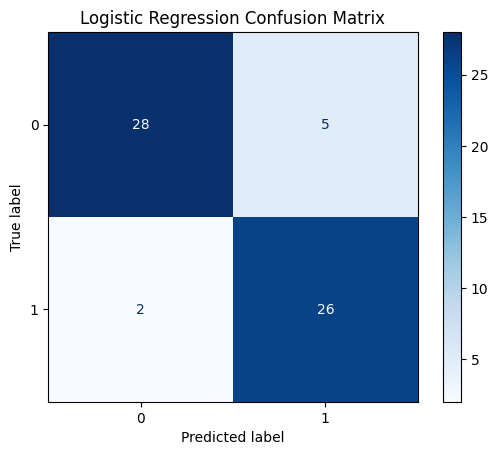

In [12]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig("lr_confusion_matrix.png")
mlflow.log_artifact("lr_confusion_matrix.png")

plt.show()

ROC Curve

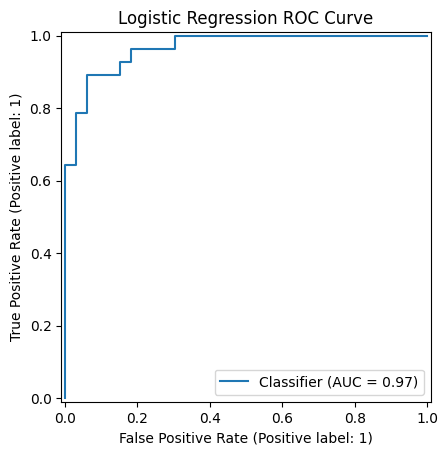

In [13]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("Logistic Regression ROC Curve")
plt.savefig("lr_roc_curve.png")
mlflow.log_artifact("lr_roc_curve.png")
plt.show()

Cross Validation

In [14]:
scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Average Accuracy:", scores.mean())

mlflow.log_metrics({
    "cv_accuracy_mean": scores.mean(),
    "cv_accuracy_std": scores.std()
})

joblib.dump(
    logistic_pipeline,
    "../models/heart_disease_model_lr.pkl"
)

mlflow.sklearn.log_model(logistic_pipeline, artifact_path="model")
mlflow.end_run()

[0.8852459  0.8852459  0.80327869 0.85       0.78333333]
Average Accuracy: 0.8414207650273224


Random Forest Pipeline

In [15]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

Train Random Forest

In [16]:
mlflow.start_run(run_name="Random_Forest")
rf_pipeline.fit(X_train, y_train)
mlflow.log_param("model_type", "RandomForestClassifier")
mlflow.log_params(rf_pipeline.named_steps["classifier"].get_params())

Predictions

In [17]:
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

Evaluate Random Forest

In [18]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

mlflow.log_metrics({
    "accuracy": accuracy, "precision": precision,
    "recall": recall, "f1_score": f1, "roc_auc": roc_auc
})

Accuracy : 0.8688524590163934
Precision: 0.8125
Recall   : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC AUC  : 0.9426406926406926


Classification Report

In [19]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



Confusion Matrix

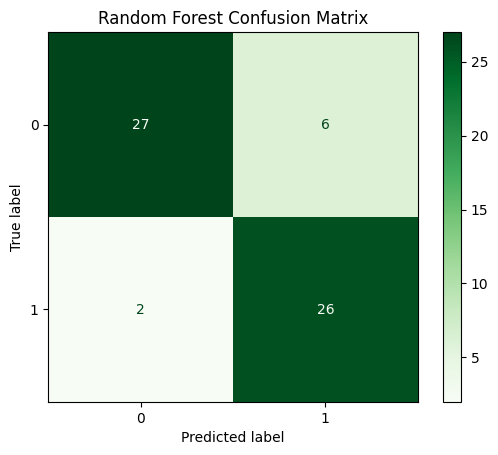

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.png")
mlflow.log_artifact("rf_confusion_matrix.png")
plt.show()

ROC Curve

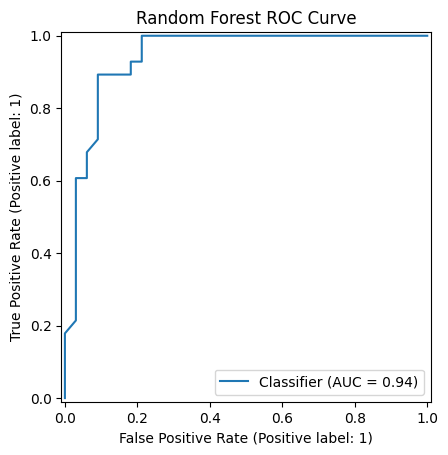

In [21]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest ROC Curve")
plt.savefig("rf_roc_curve.png")
mlflow.log_artifact("rf_roc_curve.png")
plt.show()

Cross Validation

In [22]:
scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Average Accuracy:", scores.mean())

mlflow.log_metrics({
    "cv_accuracy_mean": scores.mean(),
    "cv_accuracy_std": scores.std()
})

[0.81967213 0.90163934 0.78688525 0.81666667 0.8       ]
Average Accuracy: 0.8249726775956283


Compare Models

In [23]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.885246,0.83871,0.928571,0.881356,0.966450
1,Random Forest,0.868852,0.81250,0.928571,0.866667,0.942641


Save the Model

In [24]:
import joblib

joblib.dump(
    rf_pipeline,
    "../models/heart_disease_model_rf.pkl"
)

mlflow.sklearn.log_model(rf_pipeline, artifact_path="model")
mlflow.end_run()

print("Model Saved Successfully")

Model Saved Successfully


Test Saved Model

In [25]:
model = joblib.load("../models/heart_disease_model_rf.pkl")

prediction = model.predict(X_test.iloc[:5])

prediction

array([0, 1, 0, 0, 0], dtype=int64)

Two machine learning algorithms were selected for comparison:

Logistic Regression: a simple, interpretable baseline model.
Random Forest: an ensemble model capable of capturing nonlinear relationships.

The models were evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, and 5-fold Cross Validation.

Based on the evaluation metrics, the model with the highest ROC-AUC and balanced performance across all metrics was selected for deployment.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import numpy as np

GridSearchCV 

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best Cross Validation Accuracy:
0.8179421768707483
Accuracy : 0.8852459016393442
Precision: 0.8387096774193549
Recall   : 0.9285714285714286
F1 Score : 0.8813559322033898
ROC AUC  : 0.9512987012987013


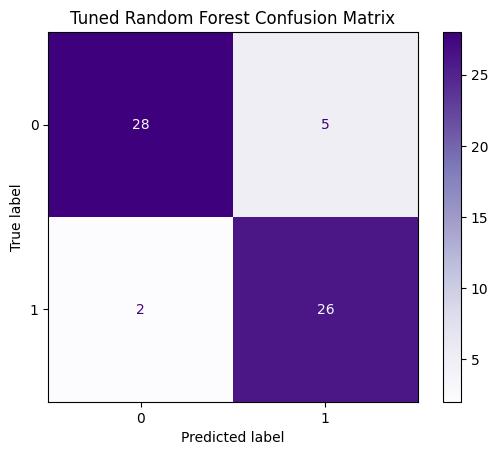

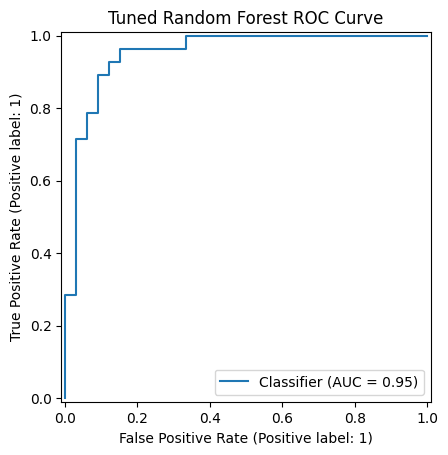

In [27]:
mlflow.start_run(run_name="RF_GridSearchCV")

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

mlflow.log_params(grid_search.best_params_)
mlflow.log_metric("best_cv_accuracy", grid_search.best_score_)

# Retrieve best model
best_rf = grid_search.best_estimator_

joblib.dump(
    best_rf,
    "../models/heart_disease_model_rf_gridsearch.pkl"
)

# Make predictions
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:,1]

# Evaluate the tuned model
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

mlflow.log_metrics({
    "accuracy": accuracy, "precision": precision,
    "recall": recall, "f1_score": f1, "roc_auc": roc_auc
})

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Purples"
)
plt.title("Tuned Random Forest Confusion Matrix")
plt.savefig("gridsearch_confusion_matrix.png")
mlflow.log_artifact("gridsearch_confusion_matrix.png")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best
)
plt.title("Tuned Random Forest ROC Curve")
plt.savefig("gridsearch_roc_curve.png")
mlflow.log_artifact("gridsearch_roc_curve.png")
plt.show()

mlflow.sklearn.log_model(best_rf, artifact_path="model")
mlflow.end_run()

RandomizedSearchCV

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'classifier__n_estimators': 150, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 10}
0.8179421768707483
Accuracy : 0.8524590163934426
Precision: 0.8064516129032258
Recall   : 0.8928571428571429
F1 Score : 0.847457627118644
ROC AUC  : 0.9502164502164502


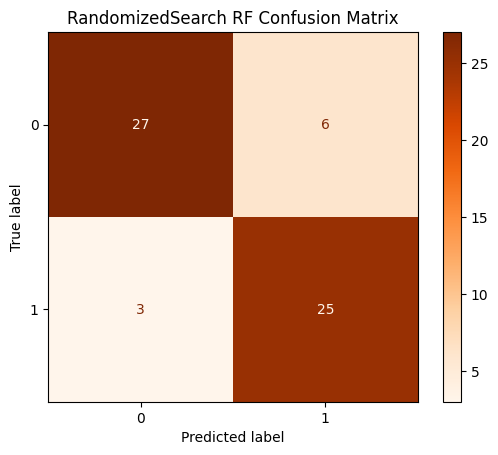

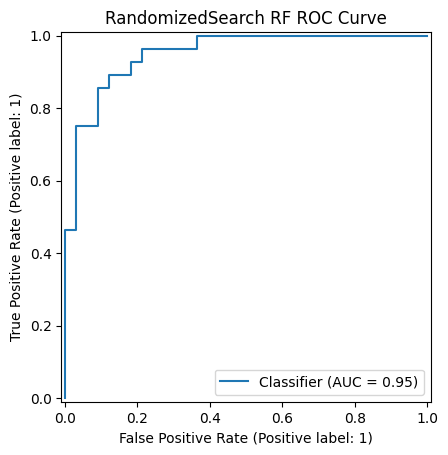

In [28]:
mlflow.start_run(run_name="RF_RandomizedSearchCV")

random_grid = {
    "classifier__n_estimators":
        np.arange(100,501,50),
    "classifier__max_depth":
        [None,5,10,15,20,25],
    "classifier__min_samples_split":
        [2,5,10],
    "classifier__min_samples_leaf":
        [1,2,4],
    "classifier__max_features":
        ["sqrt","log2"]
}

# Create Random search
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=random_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train
random_search.fit(X_train, y_train)

# Best Parameters
print(random_search.best_params_)
print(random_search.best_score_)

mlflow.log_params(random_search.best_params_)
mlflow.log_metric("best_cv_accuracy", random_search.best_score_)

best_random_rf = random_search.best_estimator_

# Evaluate
y_pred_random = best_random_rf.predict(X_test)
y_prob_random = best_random_rf.predict_proba(X_test)[:,1]

# Metrics
accuracy = accuracy_score(y_test,y_pred_random)
precision = precision_score(y_test,y_pred_random)
recall = recall_score(y_test,y_pred_random)
f1 = f1_score(y_test,y_pred_random)
roc_auc = roc_auc_score(y_test,y_prob_random)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

mlflow.log_metrics({
    "accuracy": accuracy, "precision": precision,
    "recall": recall, "f1_score": f1, "roc_auc": roc_auc
})

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_random,
    cmap="Oranges"
)
plt.title("RandomizedSearch RF Confusion Matrix")
plt.savefig("randomsearch_confusion_matrix.png")
mlflow.log_artifact("randomsearch_confusion_matrix.png")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_random
)
plt.title("RandomizedSearch RF ROC Curve")
plt.savefig("randomsearch_roc_curve.png")
mlflow.log_artifact("randomsearch_roc_curve.png")
plt.show()

mlflow.sklearn.log_model(best_random_rf, artifact_path="model")
mlflow.end_run()

Compare all models

In [29]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "GridSearch RF",
        "RandomSearch RF"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_best),
        accuracy_score(y_test,y_pred_random)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_best),
        precision_score(y_test,y_pred_random)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_best),
        recall_score(y_test,y_pred_random)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_best),
        f1_score(y_test,y_pred_random)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_best),
        roc_auc_score(y_test,y_prob_random)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.885246,0.838710,0.928571,0.881356,0.966450
1,Random Forest,0.868852,0.812500,0.928571,0.866667,0.942641
2,GridSearch RF,0.885246,0.838710,0.928571,0.881356,0.951299
3,RandomSearch RF,0.852459,0.806452,0.892857,0.847458,0.950216


Save the random search model

In [30]:
import joblib

joblib.dump(
    best_random_rf,
    "../models/heart_disease_model_random_search.pkl"
)

joblib.dump(X_test, "../models/X_test.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

['../models/y_test.pkl']

Pick and Save Final Model

In [31]:
models_dict = {
    "Logistic Regression": (logistic_pipeline, roc_auc_score(y_test, y_prob_lr)),
    "Random Forest": (rf_pipeline, roc_auc_score(y_test, y_prob_rf)),
    "GridSearch RF": (best_rf, roc_auc_score(y_test, y_prob_best)),
    "RandomSearch RF": (best_random_rf, roc_auc_score(y_test, y_prob_random)),
}

best_model_name = max(models_dict, key=lambda k: models_dict[k][1])
best_model = models_dict[best_model_name][0]

print(f"Best model: {best_model_name} (ROC-AUC={models_dict[best_model_name][1]:.4f})")

joblib.dump(best_model, "../models/final_model.pkl")
print("Saved as models/final_model.pkl")

Best model: Logistic Regression (ROC-AUC=0.9665)
Saved as models/final_model.pkl


Test the saved model

In [32]:
model = joblib.load(
    "../models/final_model.pkl"
)

prediction = model.predict(
    X_test.iloc[:5]
)

print(prediction)

[0 1 0 0 0]


Hyperparameter tuning was performed using GridSearchCV and RandomizedSearchCV with 5-fold cross-validation. Multiple combinations of Random Forest parameters were evaluated to improve predictive performance.

The tuned model with the highest cross-validation accuracy and strong performance on the test set was selected as the final model for deployment.